--2025-03-24 17:15:09--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [text/plain]
Saving to: ‘yolov3.cfg.3’

yolov3.cfg.3        100%[===================>]   8.15K  --.-KB/s    in 0s      

2025-03-24 17:15:09 (18.5 MB/s) - ‘yolov3.cfg.3’ saved [8342/8342]

--2025-03-24 17:15:09--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights.3’

yolov3.weights.3    100%[===================>] 236.52M  11.8MB/s    in 23s     

2025-03-2

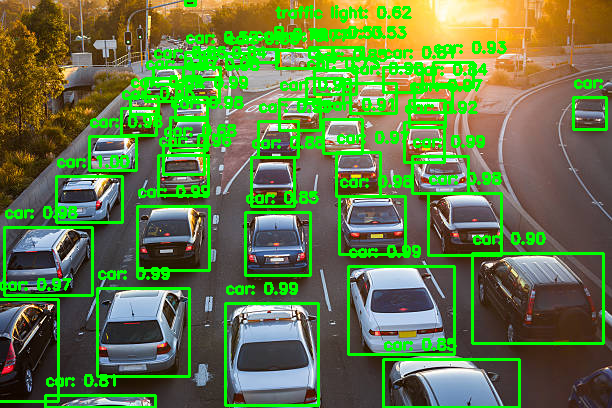

In [10]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # For Google Colab

# Download the configuration, weights, and class names files if they don't exist
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
!wget https://pjreddie.com/media/files/yolov3.weights
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names # Download coco.names

# Load YOLO model and COCO class labels
yolo_net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg") # Updated to use the downloaded file
layer_names = yolo_net.getLayerNames()
output_layers = [layer_names[i - 1] for i in yolo_net.getUnconnectedOutLayers()]

# Load class labels
with open("coco.names", "r") as f:
    classes = f.read().strip().split("\n")

# Load an image
image = cv2.imread("/content/istockphoto-159406920-612x612.jpg")  # Replace with your image file
height, width = image.shape[:2]

# Convert image to YOLO format
blob = cv2.dnn.blobFromImage(image, scalefactor=1/255.0, size=(416, 416), swapRB=True, crop=False)
yolo_net.setInput(blob)
layer_outputs = yolo_net.forward(output_layers)

# Process detections
boxes, confidences, class_ids = [], [], []
for output in layer_outputs:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]

        if confidence > 0.5:  # Confidence threshold
            box = detection[:4] * np.array([width, height, width, height])
            center_x, center_y, w, h = box.astype("int")
            x = int(center_x - (w / 2))
            y = int(center_y - (h / 2))

            boxes.append([x, y, int(w), int(h)])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply Non-Maximum Suppression (NMS) to remove redundant boxes
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

# Draw bounding boxes and labels
for i in indices.flatten():
    x, y, w, h = boxes[i]
    label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Show the result
cv2_imshow(image)